In [122]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Setting untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('Set2')

# Setting random seed untuk reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

In [123]:
torch.cuda.is_available()

True

In [124]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [125]:
device

device(type='cuda')

# Data Loading & Initial Dataset Preparation

Pada tahap ini saya akan memuat dan melakukan persiapan dataset awal dengan membersihkan dataset untuk membantu tahap EDA selanjutnya.

## Load Data

Pertama-tama saya akan memuat, memeriksa sampel, dan informasi basic dari dataset.

In [126]:
base_path = '/kaggle/input/ml-100k/'  

In [127]:
# Memuat data rating
ratings = pd.read_csv(f'{base_path}u.data', sep='\t', encoding='latin-1')

# Memuat data film

movies = pd.read_csv(f'{base_path}u.item', sep='|', encoding='latin-1')

# Memuat data pengguna

users = pd.read_csv(f'{base_path}u.user', sep='|', encoding='latin-1')


In [128]:
print(ratings.head())

   196  242  3  881250949
0  186  302  3  891717742
1   22  377  1  878887116
2  244   51  2  880606923
3  166  346  1  886397596
4  298  474  4  884182806


In [129]:
print(movies.head())

   1                                   Toy Story (1995)  01-Jan-1995  \
0  2                                   GoldenEye (1995)  01-Jan-1995   
1  3                                  Four Rooms (1995)  01-Jan-1995   
2  4                                  Get Shorty (1995)  01-Jan-1995   
3  5                                     Copycat (1995)  01-Jan-1995   
4  6  Shanghai Triad (Yao a yao yao dao waipo qiao) ...  01-Jan-1995   

   Unnamed: 3 http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)  0  0.1  \
0         NaN  http://us.imdb.com/M/title-exact?GoldenEye%20(...     0    1   
1         NaN  http://us.imdb.com/M/title-exact?Four%20Rooms%...     0    0   
2         NaN  http://us.imdb.com/M/title-exact?Get%20Shorty%...     0    1   
3         NaN  http://us.imdb.com/M/title-exact?Copycat%20(1995)     0    0   
4         NaN  http://us.imdb.com/Title?Yao+a+yao+yao+dao+wai...     0    0   

   0.2  1.1  1.2  ...  0.6  0.7  0.8  0.9  0.10  0.11  0.12  0.13  0.14  0.15  
0    1    0 

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [130]:
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   1           942 non-null    int64 
 1   24          942 non-null    int64 
 2   M           942 non-null    object
 3   technician  942 non-null    object
 4   85711       942 non-null    object
dtypes: int64(2), object(3)
memory usage: 36.9+ KB
None


In [131]:
print(movies.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1681 entries, 0 to 1680
Data columns (total 24 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   1                                                      1681 non-null   int64  
 1   Toy Story (1995)                                       1681 non-null   object 
 2   01-Jan-1995                                            1680 non-null   object 
 3   Unnamed: 3                                             0 non-null      float64
 4   http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)  1678 non-null   object 
 5   0                                                      1681 non-null   int64  
 6   0.1                                                    1681 non-null   int64  
 7   0.2                                                    1681 non-null   int64  
 8   1.1                                             

In [132]:
print(ratings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   196        99999 non-null  int64
 1   242        99999 non-null  int64
 2   3          99999 non-null  int64
 3   881250949  99999 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None


Terlihat bahwa data masih belum memiliki nama-nama kolom dan terdapat juga kolom yang perlu dikonversi ke format yang kompatibel dengan pandas, seperti kolom `release_date` di dataframe movies.

## Pemberian Nama Kolom

Langkah ini akan menambahkan nama-nama kolom tersebut yang bisa didapatkan melalui [README](data\ml-100k\README) dari dataset.

In [133]:
ratings.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

In [134]:
movies_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url',
               'unknown', 'Action', 'Adventure', 'Animation', 'Children',
               'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
               'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
               'War', 'Western']
movies.columns = movies_cols

In [135]:
users.columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

## Periksa Missing Value dan Duplikat

Selanjutnya saya perlu memeriksa missing value dan duplikat di dataset

In [136]:
print("\nMissing values di dataset ratings:")
print(ratings.isnull().sum())

print("\nMissing values di dataset movies:")
print(movies.isnull().sum())

print("\nMissing values di dataset users:")
print(users.isnull().sum())


Missing values di dataset ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values di dataset movies:
movie_id                 0
title                    0
release_date             1
video_release_date    1681
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64

Missing values di dataset users:
user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64


In [137]:
# Memeriksa duplikat di masing-masing dataset
print(f"\nJumlah duplikat di dataset ratings: {ratings.duplicated().sum()}")
print(f"Jumlah duplikat di dataset movies: {movies.duplicated(subset='movie_id').sum()}")
print(f"Jumlah duplikat di dataset users: {users.duplicated(subset='user_id').sum()}")


Jumlah duplikat di dataset ratings: 0
Jumlah duplikat di dataset movies: 0
Jumlah duplikat di dataset users: 0


Terlihat bahwa tidak ada duplikat di dataset, namun masih ada missing values yang pada dua kolom di dataset `movies`, yakni `release_date` dan `video_release_date`

## Missing Values Handling

Untuk menangani missing values pada kolom `release_date`, saya perlu mengubah tipe datanya menjadi format `datetime` Pandas terlebih dahulu.

In [138]:
# Menangani missing value pada tanggal jika ditemukan
if movies['release_date'].isnull().sum() > 0:
    # Ubah ke datetime, dengan mengabaikan kesalahan
    movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
    print(f"Jumlah tanggal rilis yang tidak valid: {movies['release_date'].isnull().sum()}")
    # Drop baris dengan tanggal rilis yang tidak valid
    movies.dropna(subset=['release_date'], inplace=True)

if movies['video_release_date'].isnull().sum() > 0:
    movies['video_release_date'].fillna('', inplace=True)
    print("Nilai kosong pada video_release_date telah diisi dengan string kosong")
    
if movies['imdb_url'].isnull().sum() > 0:
    movies['imdb_url'].fillna('', inplace=True)
    print("Nilai kosong pada imdb_url telah diisi dengan string kosong")

Jumlah tanggal rilis yang tidak valid: 1
Nilai kosong pada video_release_date telah diisi dengan string kosong
Nilai kosong pada imdb_url telah diisi dengan string kosong


/tmp/ipykernel_35/318947975.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies['video_release_date'].fillna('', inplace=True)
/tmp/ipykernel_35/318947975.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  movies['video_release_date'].fillna('', inplace=True)
/tmp/ipykernel_35/318947975.py:14: FutureWarning: A value is trying to be set on a cop

In [139]:
# Cek kembali hasil penanganan missing value
print("\nMissing values di dataset movies:")
print(movies.isnull().sum())



Missing values di dataset movies:
movie_id              0
title                 0
release_date          0
video_release_date    0
imdb_url              0
unknown               0
Action                0
Adventure             0
Animation             0
Children              0
Comedy                0
Crime                 0
Documentary           0
Drama                 0
Fantasy               0
Film-Noir             0
Horror                0
Musical               0
Mystery               0
Romance               0
Sci-Fi                0
Thriller              0
War                   0
Western               0
dtype: int64


## Data Merging

Selanjutnya saya akan menggabungkan ketiga datraframe menjadi satu dataframe untuk membantu EDA nanti. Oleh karena itu, khusus untuk dataframe movies, saya perlu membuat kolom baru berisi genre yang sebelumnya terpisah-pisah.

In [140]:
# Menciptakan kolom genre sebagai list untuk setiap film
genre_columns = movies_cols[5:]
movies['genres'] = movies.apply(
    lambda row: [genre for genre, is_genre in zip(genre_columns, row[genre_columns]) if is_genre == 1],
    axis=1
)

# Menggabungkan data
data = ratings.merge(movies[['movie_id', 'title', 'genres']], on='movie_id')
data = data.merge(users[['user_id', 'gender', 'age', 'occupation']], on='user_id')


In [141]:
# Melihat info dataset
print("\nInformasi dataset gabungan:")
data.info()


Informasi dataset gabungan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99268 entries, 0 to 99267
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     99268 non-null  int64 
 1   movie_id    99268 non-null  int64 
 2   rating      99268 non-null  int64 
 3   timestamp   99268 non-null  int64 
 4   title       99268 non-null  object
 5   genres      99268 non-null  object
 6   gender      99268 non-null  object
 7   age         99268 non-null  int64 
 8   occupation  99268 non-null  object
dtypes: int64(5), object(4)
memory usage: 6.8+ MB


In [142]:
print("\nContoh data:")
data.head()


Contoh data:


,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation
0,186,302,3,891717742,L.A. Confidential (1997),"[Crime, Film-Noir, Mystery, Thriller]",F,39,executive
1,22,377,1,878887116,Heavyweights (1994),"[Children, Comedy]",M,25,writer
2,244,51,2,880606923,Legends of the Fall (1994),"[Drama, Romance, War, Western]",M,28,technician
3,166,346,1,886397596,Jackie Brown (1997),"[Crime, Drama]",M,47,educator
4,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...,"[Sci-Fi, War]",M,44,executive


# Exploratory Data Analysis (EDA)

Waktunya untuk EDA untuk melihat distribusi dan insight data

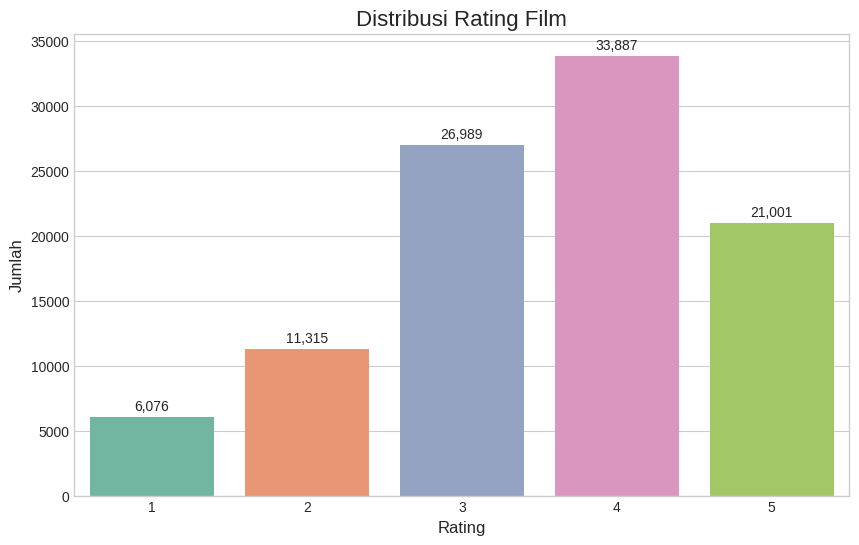

Distribusi rating:
1 stars: 6076
2 stars: 11315
3 stars: 26989
4 stars: 33887
5 stars: 21001


In [143]:
# Melihat distribusi rating
plt.figure(figsize=(10, 6))
rating_counts = data['rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Distribusi Rating Film', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
for i, count in enumerate(rating_counts.values):
    plt.text(i, count + 500, f'{count:,}', ha='center', fontsize=10)
plt.show()

print("Distribusi rating:")
for rating, count in rating_counts.items():
    print(f"{rating} stars: {count}")

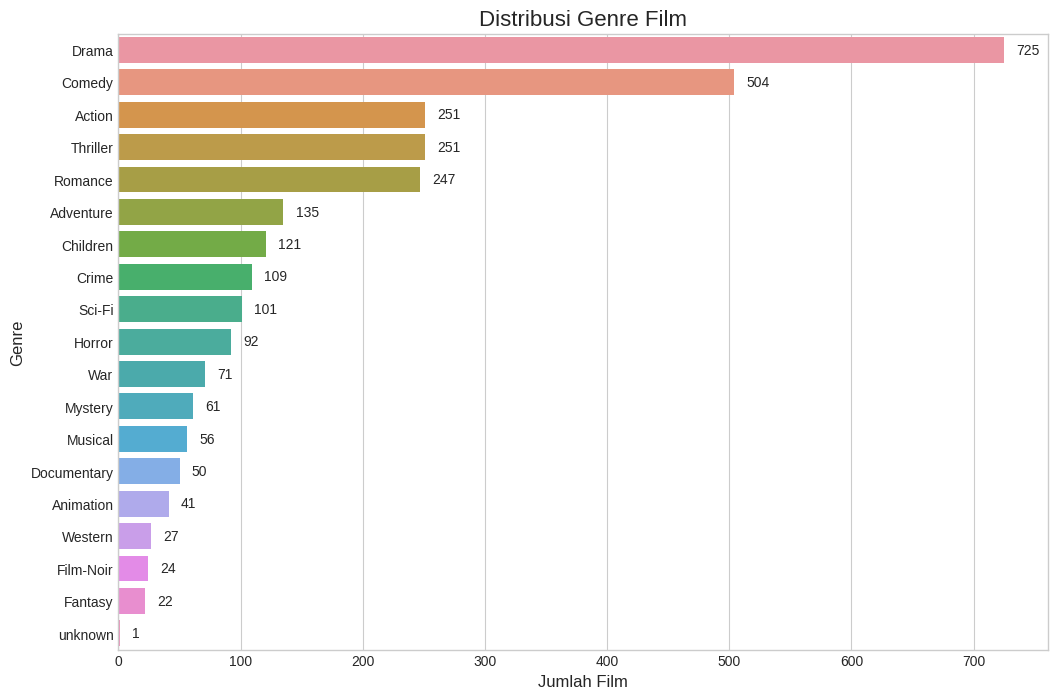

In [144]:
# Distribusi genre film
all_genres = []
for genres in movies['genres']:
    all_genres.extend(genres)

genre_counts = pd.Series(all_genres).value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Distribusi Genre Film', fontsize=16)
plt.xlabel('Jumlah Film', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
for i, count in enumerate(genre_counts.values):
    plt.text(count + 10, i, f'{count}', va='center', fontsize=10)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


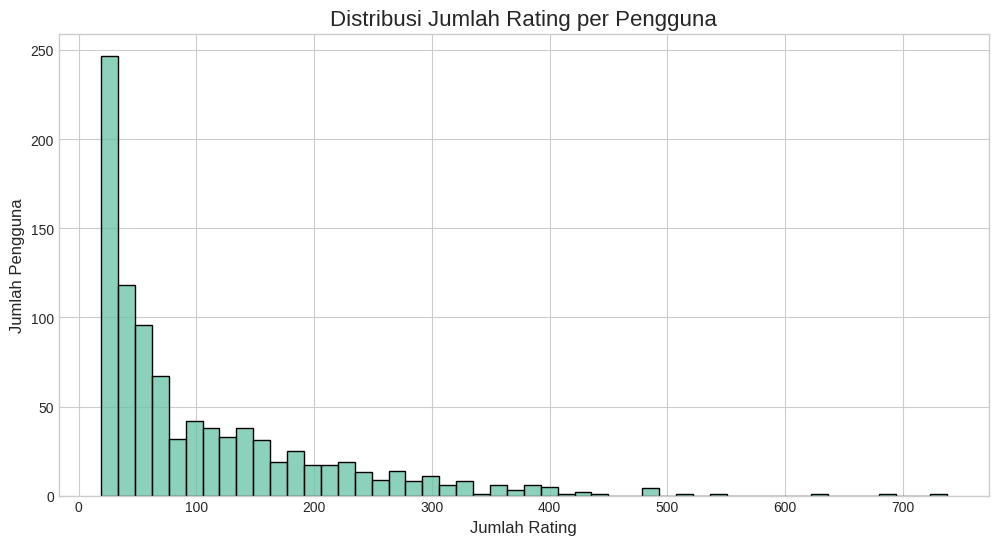

Rata-rata jumlah rating per pengguna: 105.38
Median jumlah rating per pengguna: 64.00
Min jumlah rating per pengguna: 19
Max jumlah rating per pengguna: 737


In [145]:
# Distribusi jumlah rating per pengguna
user_ratings_count = data.groupby('user_id').size()

plt.figure(figsize=(12, 6))
sns.histplot(user_ratings_count, bins=50)
plt.title('Distribusi Jumlah Rating per Pengguna', fontsize=16)
plt.xlabel('Jumlah Rating', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

print(f"Rata-rata jumlah rating per pengguna: {user_ratings_count.mean():.2f}")
print(f"Median jumlah rating per pengguna: {user_ratings_count.median():.2f}")
print(f"Min jumlah rating per pengguna: {user_ratings_count.min()}")
print(f"Max jumlah rating per pengguna: {user_ratings_count.max()}")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


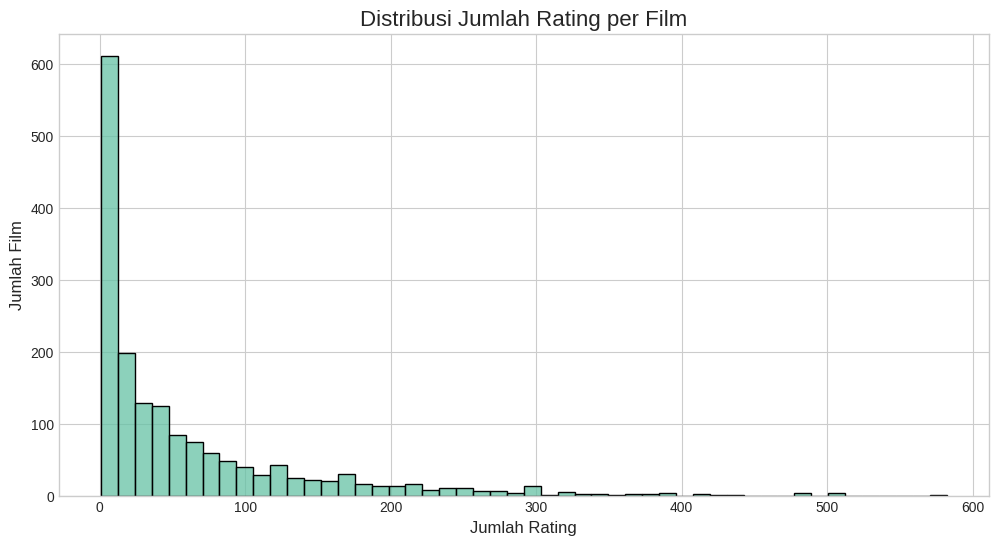

Rata-rata jumlah rating per film: 59.09
Median jumlah rating per film: 27.00
Min jumlah rating per film: 1
Max jumlah rating per film: 582


In [146]:
# Distribusi jumlah rating per film
movie_ratings_count = data.groupby('movie_id').size()

plt.figure(figsize=(12, 6))
sns.histplot(movie_ratings_count, bins=50)
plt.title('Distribusi Jumlah Rating per Film', fontsize=16)
plt.xlabel('Jumlah Rating', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

print(f"Rata-rata jumlah rating per film: {movie_ratings_count.mean():.2f}")
print(f"Median jumlah rating per film: {movie_ratings_count.median():.2f}")
print(f"Min jumlah rating per film: {movie_ratings_count.min()}")
print(f"Max jumlah rating per film: {movie_ratings_count.max()}")

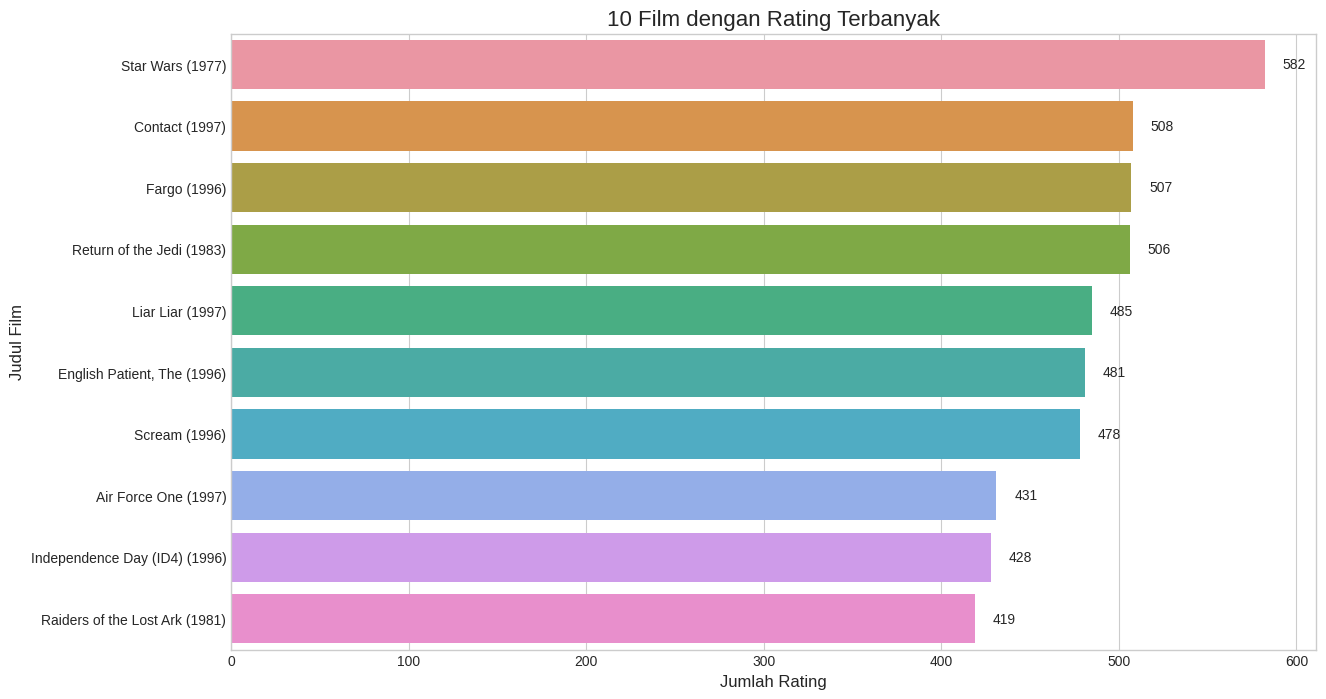

In [147]:
# Film dengan rating terbanyak
top_rated_movies = movie_ratings_count.sort_values(ascending=False).head(10)
top_movies_df = pd.DataFrame({
    'movie_id': top_rated_movies.index,
    'count': top_rated_movies.values
})
top_movies_df = top_movies_df.merge(movies[['movie_id', 'title']], on='movie_id')

plt.figure(figsize=(14, 8))
sns.barplot(x='count', y='title', data=top_movies_df)
plt.title('10 Film dengan Rating Terbanyak', fontsize=16)
plt.xlabel('Jumlah Rating', fontsize=12)
plt.ylabel('Judul Film', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
for i, count in enumerate(top_movies_df['count']):
    plt.text(count + 10, i, f'{count}', va='center', fontsize=10)
plt.show()

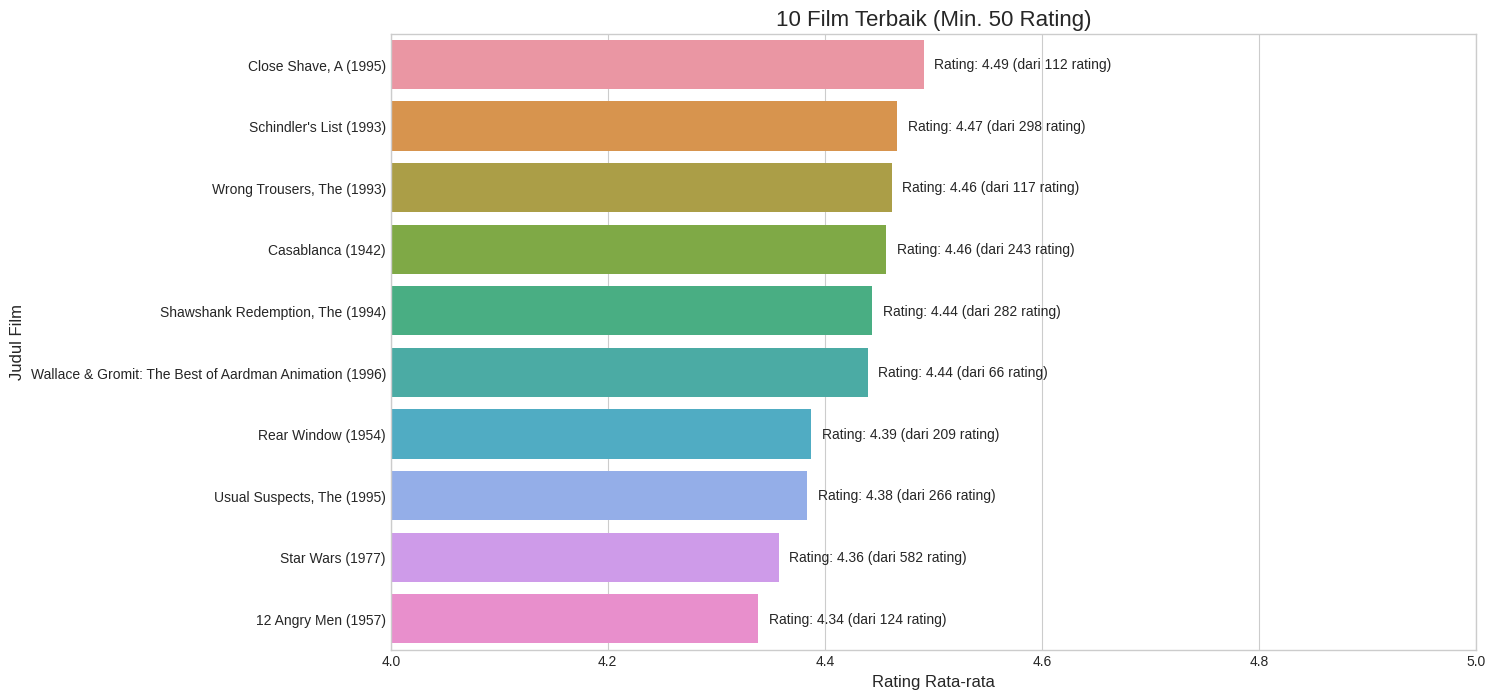

In [148]:
# Rating rata-rata per film (untuk film dengan minimal 50 rating)
movie_avg_ratings = data.groupby('movie_id')['rating'].agg(['mean', 'count'])
popular_movies = movie_avg_ratings[movie_avg_ratings['count'] >= 50].sort_values('mean', ascending=False).head(10)
popular_movies = popular_movies.reset_index()
popular_movies = popular_movies.merge(movies[['movie_id', 'title']], on='movie_id')

plt.figure(figsize=(14, 8))
sns.barplot(x='mean', y='title', data=popular_movies)
plt.title('10 Film Terbaik (Min. 50 Rating)', fontsize=16)
plt.xlabel('Rating Rata-rata', fontsize=12)
plt.ylabel('Judul Film', fontsize=12)
plt.xlim(4.0, 5.0)  # Menyesuaikan skala untuk melihat perbedaan lebih jelas
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
for i, (mean, count) in enumerate(zip(popular_movies['mean'], popular_movies['count'])):
    plt.text(mean + 0.01, i, f'Rating: {mean:.2f} (dari {count} rating)', va='center', fontsize=10)
plt.show()

Key Insights EDA:
- Distribusi rating cenderung positif dengan mayoritas rating 4 (33,950) dan 3 (27,145) bintang, menunjukkan adanya bias positif yang perlu diantisipasi dalam pengembangan model rekomendasi.
- Genre Drama, Comedy, dan Action mendominasi dataset, yang mengindikasikan ketidakseimbangan genre yang perlu diperhatikan untuk content-based filtering.
- Terdapat variasi signifikan dalam jumlah rating per pengguna (1-737) dan per film (1-583), mencerminkan masalah sparsity yang umum dalam sistem rekomendasi.
- Film-film populer mendapatkan jauh lebih banyak rating, yang dapat menciptakan popularity bias dalam collaborative filtering.

# Data Preparation untuk Modeling

Sebelum membangun model rekomendasi, perlu dilakukan persiapan data yang sesuai untuk model content-based filtering dan collaborative filtering. Pada tahap ini, saya akan:

1. **Membagi dataset** menjadi data training (80%) dan testing (20%) untuk evaluasi model
2. **Membuat mapping ID** untuk mengubah user_id dan movie_id menjadi indeks berurutan yang diperlukan model PyTorch
3. **Menerapkan mapping** tersebut ke dataset training dan testing

Untuk content-based filtering, saya akan memanfaatkan fitur genre film yang telah diproses sebelumnya. Sementara untuk collaborative filtering, kita akan menggunakan matriks interaksi user-film yang direpresentasikan oleh indeks dan nilai rating. 

In [149]:
test_size=0.2
random_state=42

# Pisahkan data untuk training dan testing
train_data, test_data = train_test_split(data, test_size=test_size, random_state=random_state)

# Untuk collaborative filtering, buat mapping user_id dan movie_id ke indeks
user_ids = data['user_id'].unique()
movie_ids = data['movie_id'].unique()

user2idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie2idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

# Terapkan mapping
train_data['user_idx'] = train_data['user_id'].map(user2idx)
train_data['movie_idx'] = train_data['movie_id'].map(movie2idx)

test_data['user_idx'] = test_data['user_id'].map(user2idx)
test_data['movie_idx'] = test_data['movie_id'].map(movie2idx)
    
print(f"Total data: {len(data)}")
print(f"Training data: {len(train_data)} ({len(train_data)/len(data)*100:.1f}%)")
print(f"Testing data: {len(test_data)} ({len(test_data)/len(data)*100:.1f}%)")
print(f"Jumlah pengguna: {len(user2idx)}")
print(f"Jumlah film: {len(movie2idx)}")

Total data: 99268
Training data: 79414 (80.0%)
Testing data: 19854 (20.0%)
Jumlah pengguna: 942
Jumlah film: 1680


# Modeling

Pada tahap modeling, saya akan mengembangkan dua pendekatan utama untuk sistem rekomendasi film:
1. **Content-Based Filtering**: Model ini merekomendasikan film berdasarkan kemiripan konten (genre) dengan film yang disukai pengguna. Menggunakan TF-IDF dan cosine similarity untuk mengukur kemiripan antar film.
2. **Collaborative Filtering**: Model ini (akan diimplementasikan setelah content-based) menggunakan pola rating pengguna untuk menemukan kesamaan preferensi antar pengguna atau film, menggunakan matriks user-item yang telah dipersiapkan.

Kedua model akan dievaluasi dengan metrik yang relevan: precision@k untuk content-based dan RMSE/MAE untuk collaborative filtering. Tujuannya adalah membandingkan kinerja kedua pendekatan dan mengidentifikasi kelebihan serta keterbatasan masing-masing untuk kasus rekomendasi film.

## Content-Based Filtering

In [150]:
class ContentBasedRecommender:
    """
    Content-based filtering untuk rekomendasi film berdasarkan kemiripan genre
    """
    def __init__(self, movies_df):
        self.movies_df = movies_df
        self.tfidf = None
        self.tfidf_matrix = None
        self.cosine_sim = None
        self.indices = None
        
    def fit(self):
        """
        Mempersiapkan model dengan menghitung similarity matrix
        """
        print("Mempersiapkan content-based recommender...")
        
        # Mengubah list genre menjadi string untuk TF-IDF
        self.movies_df['genres_str'] = self.movies_df['genres'].apply(lambda x: ' '.join(x))
        
        # Menghitung TF-IDF matrix
        self.tfidf = TfidfVectorizer(stop_words='english')
        self.tfidf_matrix = self.tfidf.fit_transform(self.movies_df['genres_str'])
        
        print(f"TF-IDF matrix shape: {self.tfidf_matrix.shape}")
        
        # Menghitung cosine similarity antar film
        print("Menghitung cosine similarity...")
        self.cosine_sim = cosine_similarity(self.tfidf_matrix, self.tfidf_matrix)
        
        # Mapping indeks film
        self.movies_df = self.movies_df.reset_index(drop=True)
        self.indices = pd.Series(self.movies_df.index, index=self.movies_df['title'])
        
        print("Content-based recommender siap digunakan")
        return self
    
    def recommend(self, title, n_recommendations=10):
        """
        Memberikan rekomendasi film berdasarkan kesamaan dengan film yang diberikan
        """
        # Mendapatkan indeks film yang sesuai dengan judul
        try:
            idx = self.indices[title]
        except KeyError:
            return f"Film dengan judul '{title}' tidak ditemukan dalam dataset."
        
        # Mendapatkan skor kesamaan dengan semua film
        sim_scores = list(enumerate(self.cosine_sim[idx]))
        
        # Mengurutkan film berdasarkan skor kesamaan
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        
        # Mendapatkan n film teratas (kecuali film itu sendiri)
        sim_scores = sim_scores[1:n_recommendations+1]
        
        # Mendapatkan indeks film
        movie_indices = [i[0] for i in sim_scores]
        
        # Mengembalikan informasi film yang direkomendasikan
        recommendations = []
        for idx in movie_indices:
            recommendations.append({
                'title': self.movies_df['title'].iloc[idx],
                'genres': self.movies_df['genres'].iloc[idx],
                'similarity_score': sim_scores[movie_indices.index(idx)][1]
            })
        
        return recommendations
    
    def get_top_n_for_user(self, user_ratings, n_recommendations=10):
        """
        Memberikan rekomendasi film untuk pengguna berdasarkan film yang telah mereka nilai
        """
        # Simpan semua skor kesamaan
        all_scores = {}
        
        # Iterasi pada setiap film yang telah dinilai oleh pengguna
        for title, rating in user_ratings.items():
            try:
                idx = self.indices[title]
                sim_scores = list(enumerate(self.cosine_sim[idx]))
                
                # Sesuaikan skor kesamaan dengan rating pengguna
                weighted_scores = [(i, score * (rating/5.0)) for i, score in sim_scores]
                
                for i, score in weighted_scores:
                    movie_title = self.movies_df['title'].iloc[i]
                    if movie_title not in user_ratings:  # Hanya rekomendasikan film yang belum dinilai
                        all_scores[i] = all_scores.get(i, 0) + score
            except KeyError:
                print(f"Film '{title}' tidak ditemukan dalam dataset.")
                continue
        
        # Urutkan film berdasarkan skor
        sorted_scores = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
        
        # Mengembalikan informasi film yang direkomendasikan
        recommendations = []
        for idx, score in sorted_scores:
            recommendations.append({
                'title': self.movies_df['title'].iloc[idx],
                'genres': self.movies_df['genres'].iloc[idx],
                'recommendation_score': score
            })
        
        return recommendations



Pada implementasi content-based filtering, saya mengembangkan kelas ContentBasedRecommender yang memanfaatkan representasi TF-IDF dari genre film untuk menghitung kemiripan antar konten. Model ini mengubah daftar genre menjadi representasi vektor, kemudian menghitung matriks kesamaan kosinus untuk memetakan hubungan kemiripan setiap film dengan film lainnya. Kelas ini menyediakan dua pendekatan rekomendasi: rekomendasi berdasarkan satu film referensi melalui metode recommend() dan rekomendasi berdasarkan profil pengguna melalui get_top_n_for_user() yang mempertimbangkan rating sebagai bobot preferensi.

## Latih Model

Selanjutnya saya tinggal fit data film ke model dan training.

In [151]:
# Buat dan latih content-based recommender
content_recommender = ContentBasedRecommender(movies)
content_recommender.fit()

Mempersiapkan content-based recommender...
TF-IDF matrix shape: (1680, 21)
Menghitung cosine similarity...
Content-based recommender siap digunakan


## Inference Content-Based Recommender

Selanjutnya saya akan mencoba menggunakan model yang sudah dilatih pada contoh sampel data film dan sampel data pengguna 

In [152]:
# Contoh penggunaan content-based recommender untuk film tertentu
movie_title = "Legends of the Fall (1994)"
recommendations = content_recommender.recommend(movie_title, n_recommendations=10)

if isinstance(recommendations, str):
    print(recommendations)
else:
    print(f"Rekomendasi film yang mirip dengan '{movie_title}':")
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec['title']} - Genre: {', '.join(rec['genres'])} - Skor Kemiripan: {rec['similarity_score']:.4f}")

Rekomendasi film yang mirip dengan 'Legends of the Fall (1994)':
1. Geronimo: An American Legend (1993) - Genre: Drama, Western - Skor Kemiripan: 0.7300
2. Gone with the Wind (1939) - Genre: Drama, Romance, War - Skor Kemiripan: 0.7270
3. English Patient, The (1996) - Genre: Drama, Romance, War - Skor Kemiripan: 0.7270
4. Casablanca (1942) - Genre: Drama, Romance, War - Skor Kemiripan: 0.7270
5. Rob Roy (1995) - Genre: Drama, Romance, War - Skor Kemiripan: 0.7270
6. Colonel Chabert, Le (1994) - Genre: Drama, Romance, War - Skor Kemiripan: 0.7270
7. Unforgiven (1992) - Genre: Western - Skor Kemiripan: 0.6866
8. Tombstone (1993) - Genre: Western - Skor Kemiripan: 0.6866
9. Wild Bill (1995) - Genre: Western - Skor Kemiripan: 0.6866
10. Wyatt Earp (1994) - Genre: Western - Skor Kemiripan: 0.6866


In [153]:
# Contoh penggunaan content-based recommender untuk pengguna dengan beberapa rating
user_ratings = {
    "Legends of the Fall (1994)": 5,
    "Star Wars (1977)": 5,
    "Pulp Fiction (1994)": 4,
    "Shawshank Redemption, The (1994)": 5,
    "Terminator, The (1984)": 3
}

recommendations = content_recommender.get_top_n_for_user(user_ratings, n_recommendations=10)

print("Rekomendasi film berdasarkan rating pengguna:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec['title']} - Genre: {', '.join(rec['genres'])} - Skor Rekomendasi: {rec['recommendation_score']:.4f}")

Rekomendasi film berdasarkan rating pengguna:
1. Empire Strikes Back, The (1980) - Genre: Action, Adventure, Drama, Romance, Sci-Fi, War - Skor Rekomendasi: 2.0740
2. Crying Game, The (1992) - Genre: Action, Drama, Romance, War - Skor Rekomendasi: 1.8106
3. Return of the Jedi (1983) - Genre: Action, Adventure, Romance, Sci-Fi, War - Skor Rekomendasi: 1.7806
4. Gone with the Wind (1939) - Genre: Drama, Romance, War - Skor Rekomendasi: 1.7379
5. English Patient, The (1996) - Genre: Drama, Romance, War - Skor Rekomendasi: 1.7379
6. Casablanca (1942) - Genre: Drama, Romance, War - Skor Rekomendasi: 1.7379
7. Rob Roy (1995) - Genre: Drama, Romance, War - Skor Rekomendasi: 1.7379
8. Colonel Chabert, Le (1994) - Genre: Drama, Romance, War - Skor Rekomendasi: 1.7379
9. Sneakers (1992) - Genre: Crime, Drama, Sci-Fi - Skor Rekomendasi: 1.6946
10. Braveheart (1995) - Genre: Action, Drama, War - Skor Rekomendasi: 1.6646


Terlihat bahwa model bisa bekerja dengan baik! 

## Evaluasi Content-Based Recommender

Pada bagian ini, saya akan mengevaluasi kualitas rekomendasi yang dihasilkan oleh model Content-Based Recommender dengan menggunakan metrik precision@k. Metrik ini mengukur proporsi film yang direkomendasikan yang memiliki kesamaan genre dengan film referensi, sehingga dapat menilai relevansi rekomendasi dari perspektif konten. Evaluasi akan dilakukan terhadap beberapa film populer sebagai sampel untuk mendapatkan gambaran umum tentang efektivitas model dalam memberikan rekomendasi yang sesuai dengan preferensi genre pengguna

In [154]:
# Fungsi untuk menghitung precision@k untuk evaluasi content-based recommender
def calculate_precision_at_k(recommender, test_movie, k=10):
    """
    Menghitung precision@k untuk sebuah film uji
    """
    # Dapatkan genre film uji
    try:
        test_idx = recommender.indices[test_movie]
        test_genres = set(recommender.movies_df['genres'].iloc[test_idx])
    except KeyError:
        return None
    
    # Dapatkan rekomendasi
    recommendations = recommender.recommend(test_movie, n_recommendations=k)
    if isinstance(recommendations, str):
        return None
    
    # Hitung precision
    relevant_count = 0
    for rec in recommendations:
        rec_genres = set(rec['genres'])
        if len(test_genres.intersection(rec_genres)) > 0:  # Jika ada genre yang sama
            relevant_count += 1
    
    precision = relevant_count / k
    return precision

# Evaluasi content-based recommender untuk beberapa film populer
popular_movies_titles = [
    "Toy Story (1995)",
    "Star Wars (1977)",
    "Pulp Fiction (1994)",
    "Shawshank Redemption, The (1994)",
    "Jurassic Park (1993)"
]

print("Evaluasi Content-Based Recommender dengan Precision@10:")
precisions = []
for title in popular_movies_titles:
    precision = calculate_precision_at_k(content_recommender, title, k=10)
    if precision is not None:
        precisions.append(precision)
        print(f"{title} - Precision@10: {precision:.2f}")

print(f"\nRata-rata Precision@10: {np.mean(precisions):.4f}")

Evaluasi Content-Based Recommender dengan Precision@10:
Star Wars (1977) - Precision@10: 1.00
Pulp Fiction (1994) - Precision@10: 1.00
Shawshank Redemption, The (1994) - Precision@10: 1.00
Jurassic Park (1993) - Precision@10: 1.00

Rata-rata Precision@10: 1.0000


Hasil evaluasi menunjukkan bahwa model Content-Based Recommender mencapai skor Precision@10 sempurna (1.0) pada semua film populer yang diuji, membuktikan bahwa sistem rekomendasi berhasil memberikan rekomendasi yang sangat relevan dengan selalu menyertakan film-film dengan genre yang serupa dengan film referensi.

## Collaborative Filtering

Untuk pembuatan model collaborative filtering, saya akan menggunakan Pytorch dibantu dengan PyTorch Lightning. 

### Setup DataModule

Serupa dengan TensorFlow dan Keras, pada PyTorch saya juga perlu mempersiapkan terlebih dahulu sebuah struktur data yang dibutuhkan untuk menangani proses loading, batching, dan transformasi data rating film untuk tahap training dan evaluasi model. 

In [155]:
class MovieLensDataset(Dataset):
    """Dataset MovieLens untuk collaborative filtering"""
    
    def __init__(self, ratings_df):
        self.ratings = ratings_df
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        user_idx = self.ratings.iloc[idx]['user_idx']
        movie_idx = self.ratings.iloc[idx]['movie_idx']
        rating = self.ratings.iloc[idx]['rating']
        
        return {
            'user_idx': torch.tensor(user_idx, dtype=torch.long),
            'movie_idx': torch.tensor(movie_idx, dtype=torch.long),
            'rating': torch.tensor(rating, dtype=torch.float)
        }

class MovieLensDataModule(pl.LightningDataModule):
    """Lightning DataModule untuk MovieLens dataset"""
    
    def __init__(self, train_df, test_df, batch_size=64):
        super().__init__()
        self.train_df = train_df
        self.test_df = test_df
        self.batch_size = batch_size
        
    def setup(self, stage=None):
        self.train_dataset = MovieLensDataset(self.train_df)
        self.test_dataset = MovieLensDataset(self.test_df)
        
    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=2,
            persistent_workers=True
        )
        
    def val_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            persistent_workers=True
        )
        
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2
            ,persistent_workers=True
        )

Di sini saya mengikuti best practice dengan mendefinisikan kelas `Dataset` dari PyTorch dalam membuat struktur data dan menggunakan library `DataModule` dari Lightning untuk mempersipakan DataLoader.

### Build Model

In [156]:
class CollaborativeFilteringModel(pl.LightningModule):
    """Model collaborative filtering menggunakan matrix factorization"""
    
    def __init__(self, n_users, n_movies, embedding_dim=50, lr=1e-3):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        self.lr = lr
        
        # Inisialisasi parameter
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
        
        # Logging hyperparameters
        self.save_hyperparameters()
        
    def forward(self, user_idx, movie_idx):
        # Embedding pengguna dan film
        user_emb = self.user_embedding(user_idx)
        movie_emb = self.movie_embedding(movie_idx)
        
        # Bias
        user_b = self.user_bias(user_idx).squeeze()
        movie_b = self.movie_bias(movie_idx).squeeze()
        
        # Prediksi rating: dot product dari embedding + bias
        pred = torch.sum(user_emb * movie_emb, dim=1) + user_b + movie_b + self.global_bias
        
        return pred
    
    def training_step(self, batch, batch_idx):
        user_idx = batch['user_idx']
        movie_idx = batch['movie_idx']
        rating = batch['rating']
        
        pred = self(user_idx, movie_idx)
        loss = nn.MSELoss()(pred, rating)
        
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        user_idx = batch['user_idx']
        movie_idx = batch['movie_idx']
        rating = batch['rating']
        
        pred = self(user_idx, movie_idx)
        loss = nn.MSELoss()(pred, rating)
        
        self.log('val_loss', loss, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        user_idx = batch['user_idx']
        movie_idx = batch['movie_idx']
        rating = batch['rating']
        
        pred = self(user_idx, movie_idx)
        loss = nn.MSELoss()(pred, rating)
        
        # Menghitung RMSE
        rmse = torch.sqrt(loss)
        self.log('test_rmse', rmse, prog_bar=True)
        
        return {'test_loss': loss, 'test_rmse': rmse}
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    
    def recommend_movies(self, user_idx, movie_data, n_recommendations=10, exclude_rated=True, rated_movies=None):
        """
        Memberikan rekomendasi film untuk pengguna tertentu
        """
        self.eval()  # Set model ke mode evaluasi
        
        # Konversi user_idx ke tensor
        user_tensor = torch.tensor([user_idx] * len(movie_data), dtype=torch.long)
        
        # Mendapatkan seluruh indeks film
        movie_indices = torch.tensor(movie_data.index.values, dtype=torch.long)
        
        with torch.no_grad():
            # Prediksi rating untuk semua film
            predicted_ratings = self(user_tensor, movie_indices)
            
        # Konversi ke NumPy
        predicted_ratings = predicted_ratings.cpu().numpy()
        
        # Masukkan prediksi ke movie_data
        recommendations = movie_data.copy()
        recommendations['predicted_rating'] = predicted_ratings
        
        # Jika perlu, hapus film yang telah dinilai
        if exclude_rated and rated_movies is not None:
            recommendations = recommendations[~recommendations['movie_id'].isin(rated_movies)]
        
        # Sortir berdasarkan prediksi rating tertinggi
        recommendations = recommendations.sort_values(by='predicted_rating', ascending=False)
        
        # Kembalikan n film teratas
        return recommendations.head(n_recommendations)

- Jadi di sini saya mengimplementasikan arsitektur collaborative filtering berbasis matrix factorization yang merepresentasikan pengguna dan film dalam ruang embedding berdimensi rendah. 
- Model ini mempelajari vektor embedding untuk setiap pengguna dan film, serta parameter bias untuk masing-masing, dengan prediksi rating dihitung melalui dot product antara embedding pengguna dan film ditambah dengan bias.
- Implementasi menggunakan MSE loss untuk training dan validasi, serta RMSE untuk evaluasi, dengan optimizer Adam untuk pembelajaran parameter.
- Model ini akan memprediksi rating untuk semua film bagi pengguna tertentu dan mengembalikan rekomendasi film teratas yang belum pernah dinilai pengguna.

### Latih Model

Waktunya latih model dengan fit data movies ke model yang dibuat. Dalam melatih saya akan mengikuti best practice dengan mengimplementasikan checkpointing untuk mempermudah menyimpan dan melanjutkan pelatihan model, early stopping untuk menghindari overfitting, serta logging hasil training model ke CSV melalui callback.

In [157]:
# Siapkan DataModule
data_module = MovieLensDataModule(train_data, test_data, batch_size=512)

# Siapkan model
n_users = len(user2idx)
n_movies = len(movie2idx)
model = CollaborativeFilteringModel(n_users, n_movies, embedding_dim=50, lr=1e-3)

In [158]:
# Callbacks
checkpoint_callback = ModelCheckpoint(
    dirpath='./models',
    filename='collaborative_model-{epoch:02d}-{val_loss:.4f}',
    save_top_k=2,
    monitor='val_loss',
    mode='min'
)

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min'
)

# Logger
logger = CSVLogger(save_dir='./logs', name='collaborative_filtering')

# Trainer
trainer = pl.Trainer(
    max_epochs=20,  # Kurangi jumlah epoch untuk notebook
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    accelerator='auto',  # Gunakan GPU jika tersedia
    log_every_n_steps=10,
    num_sanity_val_steps=0 
)


INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs


In [159]:
trainer.fit(model, data_module)

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /kaggle/working/models exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name            | Type      | Params | Mode 
------------------------------------------------------
0 | user_embedding  | Embedding | 47.1 K | train
1 | movie_embedding | Embedding | 84.0 K | train
2 | user_bias       | Embedding | 942    | train
3 | movie_bias      | Embedding | 1.7 K  | train
  | other params    | n/a       | 1      | n/a  
------------------------------------------------------
133 K     Trainable params
0         Non-trainable params
133 K     Total params
0.535     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.


In [162]:
torch.save(model.state_dict(), './models/collaborative_model_final.pt')

In [164]:
!zip -r model.zip /kaggle/working/models

  adding: kaggle/working/models/ (stored 0%)
  adding: kaggle/working/models/collaborative_model_final.pt (deflated 8%)
  adding: kaggle/working/models/collaborative_model-epoch=04-val_loss=1.5248.ckpt (deflated 8%)
  adding: kaggle/working/models/collaborative_model-epoch=03-val_loss=2.8454.ckpt (deflated 8%)
  adding: kaggle/working/models/collaborative_model-epoch=16-val_loss=0.8893.ckpt (deflated 8%)
  adding: kaggle/working/models/collaborative_model-epoch=17-val_loss=0.8881.ckpt (deflated 8%)


In [165]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip

In [166]:
!zip -r logs.zip /kaggle/working/logs

  adding: kaggle/working/logs/ (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/ (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_1/ (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_1/hparams.yaml (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_2/ (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_2/hparams.yaml (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_2/metrics.csv (deflated 52%)
  adding: kaggle/working/logs/collaborative_filtering/version_0/ (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_0/hparams.yaml (stored 0%)
  adding: kaggle/working/logs/collaborative_filtering/version_0/metrics.csv (deflated 41%)


In [167]:
from IPython.display import FileLink
FileLink(r'logs.zip')

/kaggle/working/logs.zip